In [22]:
using Luxor
using Colors
using Plots
using IterTools
using DataFrames
using OpenStreetMapX
using LightOSM
using KernelDensity
using Downloads
using CSV
include("kernel_density.jl")
include("distance.jl")
include("prepare_data.jl")
include("analyse.jl")
include("plots.jl")
include("/home/adamkas/Julia/map_analyses/OSMXGraph/src/OSMXGraph.jl")
using .OSMXGraph
using Makie
using GeoMakie
using CairoMakie
using GraphMakie
using NaturalEarth

In [21]:
road_types = ["motorway", "trunk", "primary", "secondary", 
"tertiary", "residential", "service", "living_street", 
"motorway_link", "trunk_link", "primary_link", "secondary_link", 
"tertiary_link"] 

data = "data"
city = "Warsaw"
admin_level = ""
search_area = 1000
attr = :education
wilderness_distance = 300
shape = "rectangle"
calculate_percent = true
num_of_points = 360
distance_sectors = 200.0
scrape_config = "poi_config_test.csv"
city_sector = prepare_city_map(
            city, #city_name
            admin_level, #admin_level
            search_area, #search_area
            wilderness_distance, #wilderness_distance
            shape; #shape
            calculate_percent = true,
            num_of_points = num_of_points,
            scrape_config = scrape_config,
            dir=data)
osm_file = "$city.osm"
dir_in = "data"
parsed = OpenStreetMapX.parseOSM(string(dir_in,"/",osm_file))
ways = parsed.ways
filtered_ways = OSMXGraph.filter_ways(ways,road_types)
roads_all, road_tags, nds_all = OSMXGraph.find_all_points(filtered_ways, parsed)
edges = OSMXGraph.ways_to_edges(roads_all,road_tags,parsed,nds_all)
df = OSMXGraph.edges_to_df(edges)
sparse_index = OSMXGraph.create_sparse_index(df.from_id,df.to_id,df.id)
warsaw_center = city_sector[2]
nodes = df[:,:from_LLA]
rslts, center_kde = kernel_density_roads(city_sector,nodes)

┌ Info: Read map data from cache data/Warsaw.osm.cache
└ @ OpenStreetMapX /home/adamkas/.julia/packages/OpenStreetMapX/gCd33/src/parseMap.jl:97


([0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], 2.8862576265036187e-9)

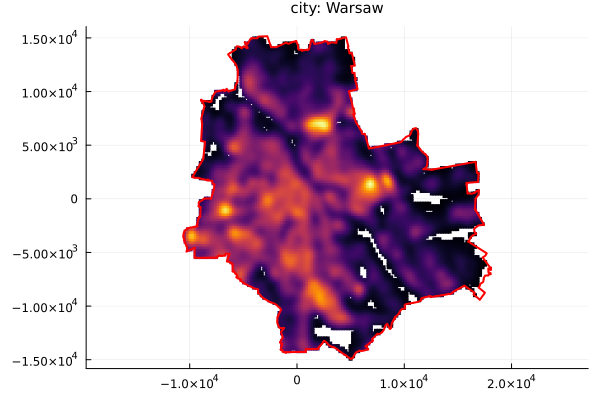

In [24]:
p = plot_density_heatmap(city_sector[1],rslts,city_sector[5],"Warsaw")

In [25]:
savefig(p, "warsaw_density.svg")

"/home/adamkas/Julia/map_analyses/map_analyses/warsaw_density.svg"

In [26]:
city_df = CSV.read("KDE_results_final.csv",DataFrame;types = Dict("City" => String))
cities_list = city_df.City

108-element Vector{String}:
 "Manchester"
 "Chicago"
 "Kansas City"
 "Berlin"
 "Dallas"
 "Austin"
 "Madrid"
 "Porto"
 "Jacksonville"
 "Houston"
 ⋮
 "Luxembourg"
 "Ljubljana"
 "Split"
 "Sarajevo"
 "Ghent"
 "Bern"
 "Graz"
 "Rennes"
 "Palermo"

In [27]:
dfs = [CSV.read(string("data/",city,"_bounds.csv"),DataFrame) for city in cities_list]
df_loc = vcat(dfs...)
city_df[!,"mean_lat"] = (df_loc.maxlat .+ df_loc.minlat)./2
city_df[!,"mean_lon"] = (df_loc.maxlon .+ df_loc.minlon)./2


108-element Vector{Float64}:
  -2.23337365
 -87.73208439999999
 -94.57571949999999
  13.42475295
 -96.73205684999999
 -97.74864755
  -3.7034351
  -8.62164275
 -81.68305075
 -95.4608972
   ⋮
   6.13640955
  14.5819745
  16.4590756
  18.3638063
   3.71455145
   7.3949354
  15.44195735
  -1.68849605
  13.347152300000001

In [28]:
CSV.write("city_df.csv",city_df)

"city_df.csv"

In [42]:
#admin_1_states_provinces
admin_1_df = DataFrame(naturalearth("admin_0_countries", 110))
filter!(row -> row[:WB_A3] in ("USA", "CAN"), admin_1_df)
filter!(row -> row[:WB_A3] != "USA" || !(row[:NAME_SORT] in ("Hawaii", "Puerto Rico")), admin_1_df)
admin_1_df.geometry = GeoMakie.to_multipoly.(admin_1_df.geometry)
n = size(admin_1_df, 1)
fig = Figure(size = (1200, 800), fontsize = 22)
ga = GeoAxis(
    fig[1, 1],
    source = "+proj=longlat +datum=WGS84",
    dest   = "+proj=merc +lon_0=0 +lat_ts=0 +datum=WGS84",
    title = "USA and Canada",
)

GeoAxis()

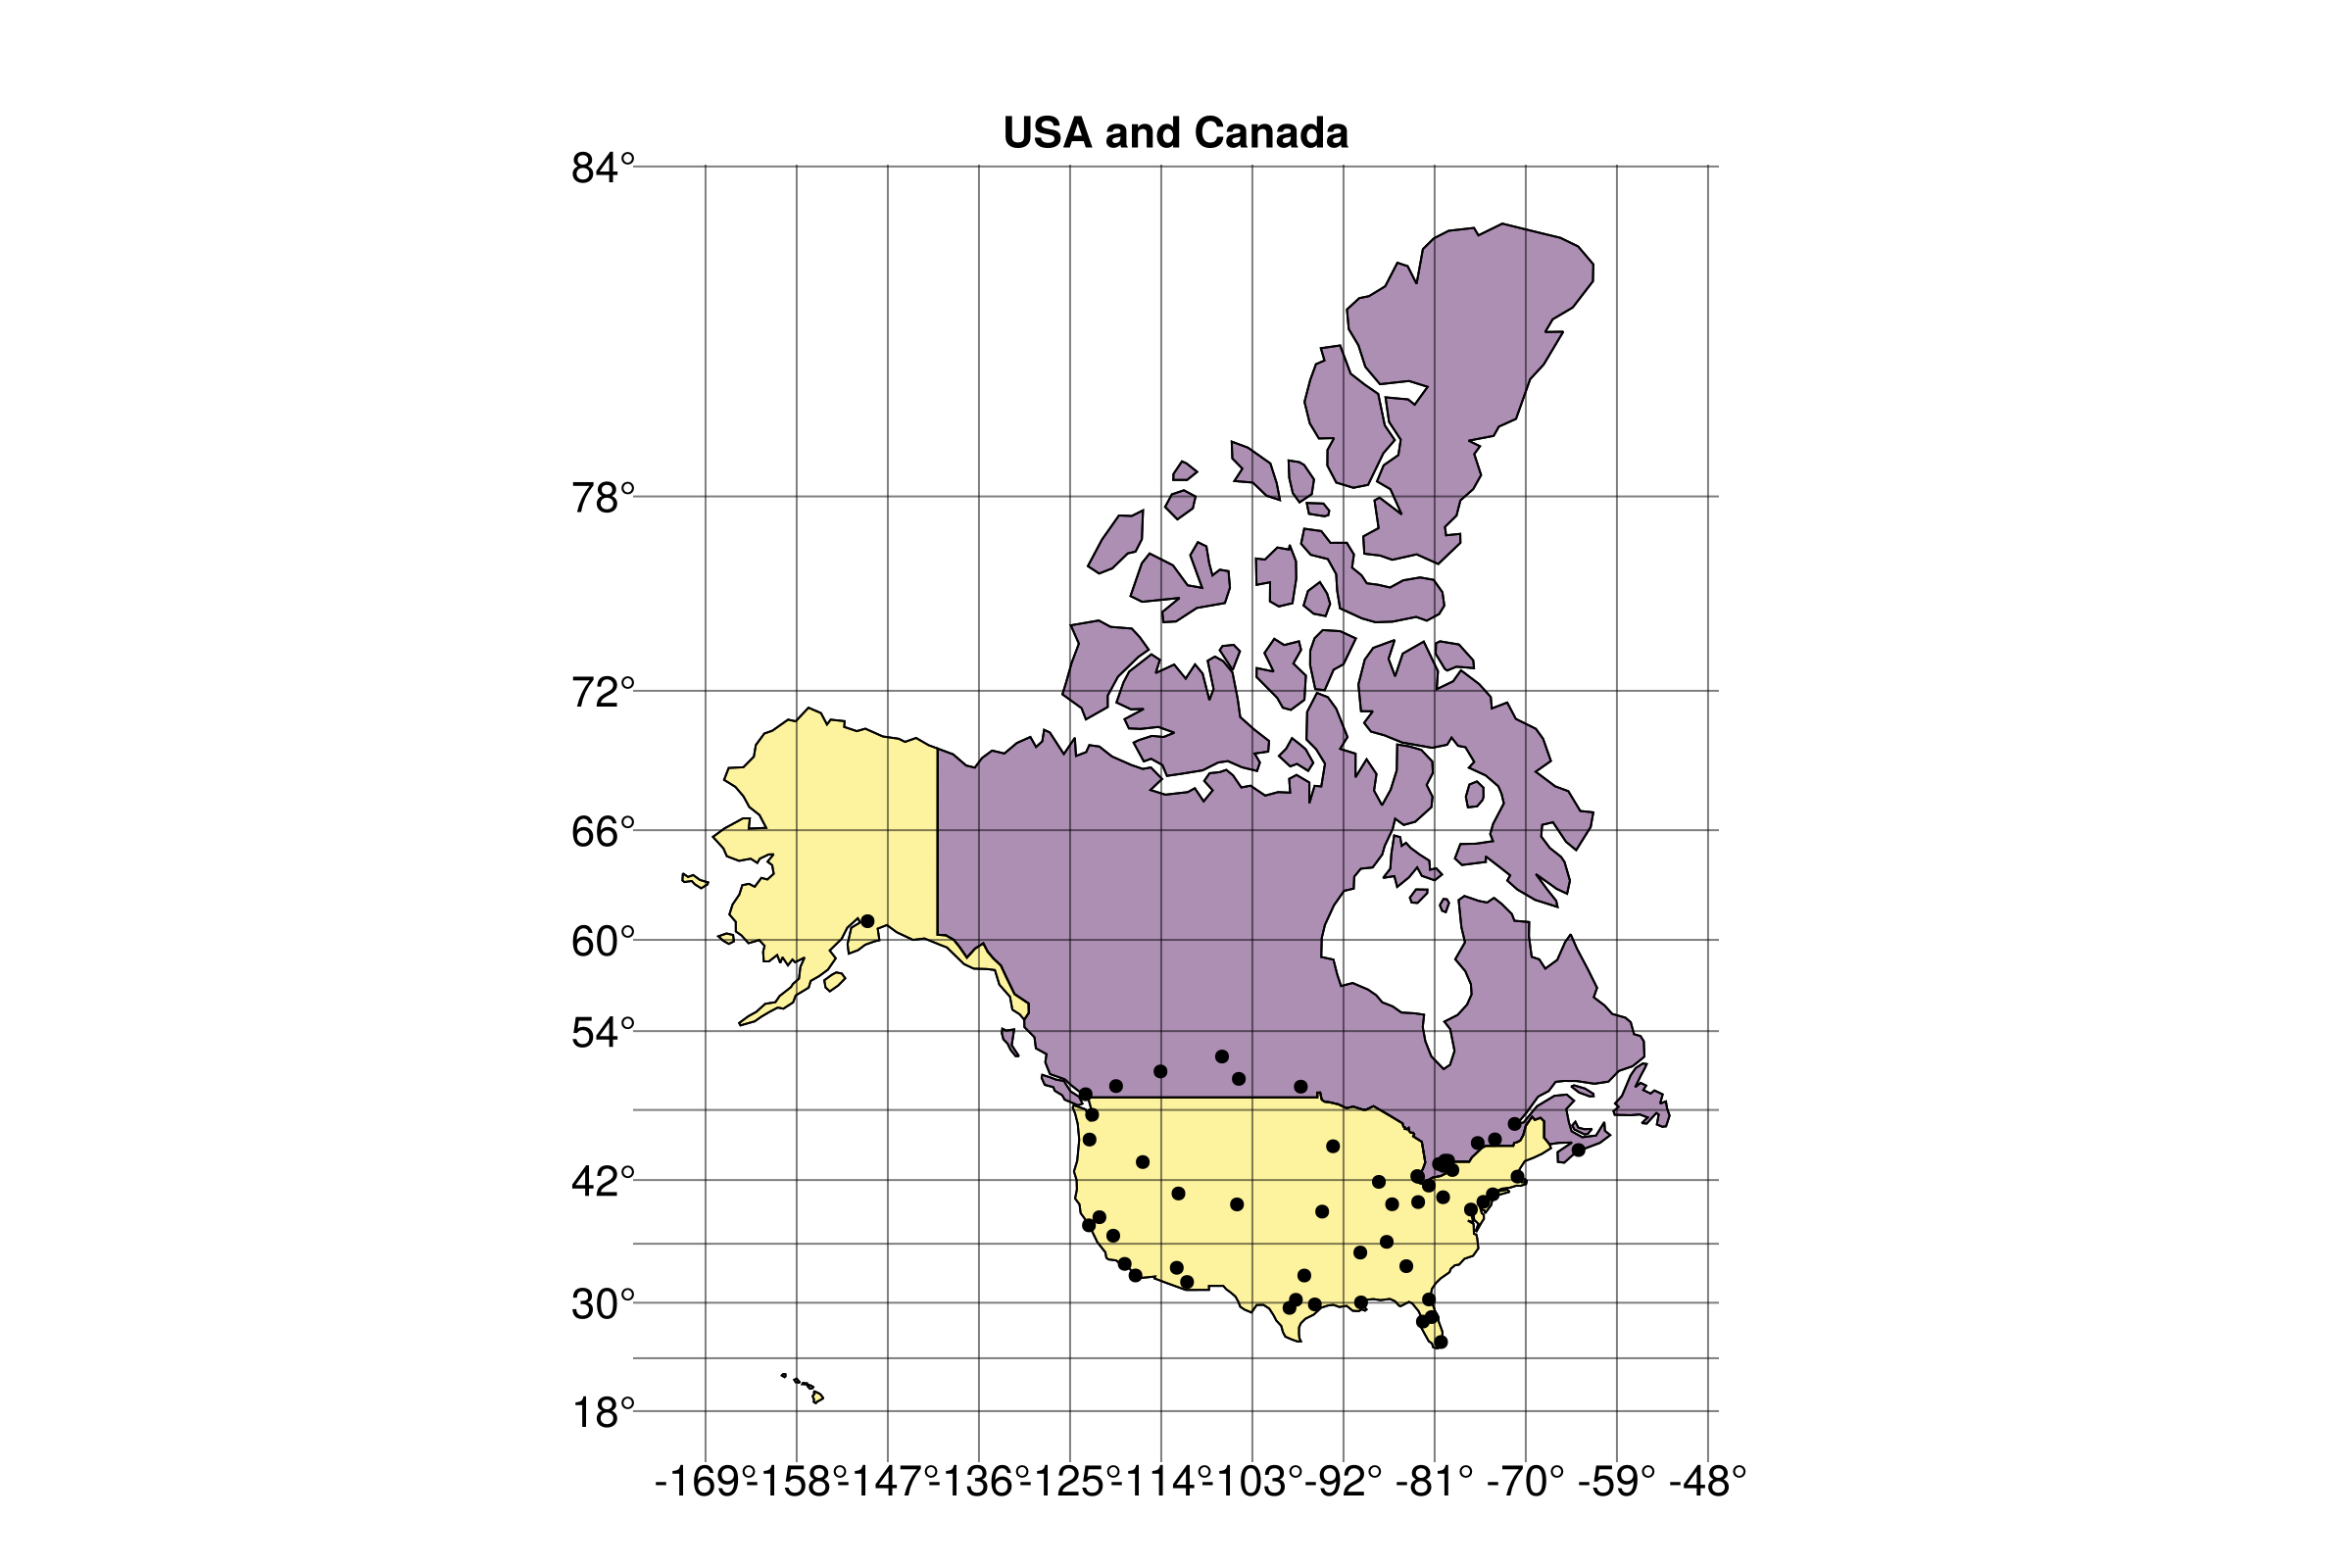

In [43]:
poly!(
    ga, admin_1_df.geometry;
    color = 1:n, colormap = (:viridis, 0.25),
    strokecolor = :black, strokewidth = 1
)
fig
am = city_df[city_df.continent .== "a", [:mean_lat, :mean_lon]]
poly!(
    ga,
    admin_1_df.geometry;
    color        = 1:size(admin_1_df, 1),
    colormap     = (:viridis, 0.25),
    strokecolor  = :black,
    strokewidth  = 1
)

# 5. Plot the city points on the same GeoAxis
#    IMPORTANT: pass (lon, lat) = (am.mean_lon, am.mean_lat)
Makie.scatter!(
    ga,
    am.mean_lon,
    am.mean_lat;
    color       = :black,
    strokecolor = (:black, 0.2),
    markersize  = 10
)
fig
#save("cities_America.svg",fig)
#am = city_df[city_df.continent .== "a"][["mean_lat","mean_lon"]]
#GeoMakie.scatter!(ga, am.mean_lon,am.mean_lat; color="black", strokecolor = (:black, 0.2))

In [ ]:
#admin_1_states_provinces
admin_1_df = DataFrame(naturalearth("admin_0_countries", 110))
filter!(row -> row[:REGION_UN] .== ("Europe"), admin_1_df)
filter!(row -> row[:WB_A3] != "RUS", admin_1_df)
admin_1_df.geometry = GeoMakie.to_multipoly.(admin_1_df.geometry)
n = size(admin_1_df, 1)
fig = Figure(size = (800, 1200), fontsize = 22)
bb = boundingbox(((-10, 35), (30, 70)))
ga = GeoAxis(
    region = bb,
    fig[1, 1],
    source = "+proj=longlat +datum=WGS84",
    dest   = "+proj=merc +lon_0=0 +lat_ts=0 +datum=WGS84",
    title = "Europe")

MethodError: MethodError: no method matching foreach_plot(::Makie.var"#1103#1105"{Makie.var"#1102#1104", Symbol, Base.RefValue{GeometryBasics.HyperRectangle{3, Float64}}}, ::Tuple{Tuple{Int64, Int64}, Tuple{Int64, Int64}})

Closest candidates are:
  foreach_plot(::Any, !Matched::Makie.Scene)
   @ Makie ~/.julia/packages/Makie/6c4lt/src/layouting/data_limits.jl:269
  foreach_plot(::Any, !Matched::Plot)
   @ Makie ~/.julia/packages/Makie/6c4lt/src/layouting/data_limits.jl:273
  foreach_plot(::Any, !Matched::AbstractVector)
   @ Makie ~/.julia/packages/Makie/6c4lt/src/layouting/data_limits.jl:272


In [ ]:
am = city_df[city_df.continent .== "e", [:mean_lat, :mean_lon]]
poly!(
    ga,
    admin_1_df.geometry;
    color        = 1:size(admin_1_df, 1),
    colormap     = (:viridis, 0.25),
    strokecolor  = :black,
    strokewidth  = 1
)

Makie.scatter!(
    ga,
    am.mean_lon,
    am.mean_lat;
    color       = :black,
    strokecolor = (:black, 0.2),
    markersize  = 10
)
fig
#save("cities_Europe.svg",fig)

CairoMakie.Screen{SVG}
